# **FINAL PYTHON PROJECT — End-to-End Data Analytics Project ProjectName:Retail Sales Analytics using Python**

Original Data:
     Product      Region   Price  Quantity
0   Monitor  Manchester  1706.0         1
1   Headset  Manchester   981.0         1
2  Keyboard  Manchester  1682.0         4
3   Headset  Birmingham   174.0         2
4   Headset  Birmingham   509.0         3

Merged Data:
     Product      Region   Price  Quantity  Revenue Category  CustomerID  \
0   Monitor  Manchester  1706.0         1   1706.0     High           1   
1   Headset  Manchester   981.0         1    981.0      Low           2   
2  Keyboard  Manchester  1682.0         4   6728.0     High           3   
3   Headset  Birmingham   174.0         2    348.0      Low           4   
4   Headset  Birmingham   509.0         3   1527.0     High           5   

  LoyaltyTier  
0        Gold  
1        Gold  
2        Gold  
3      Silver  
4        Gold  


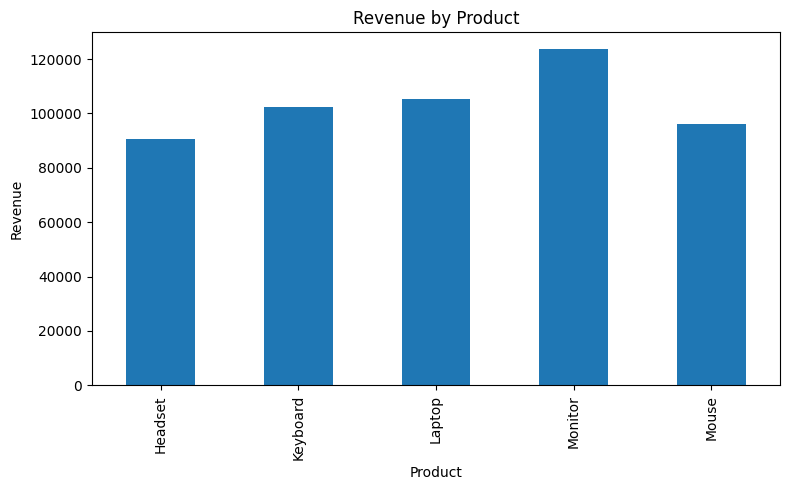

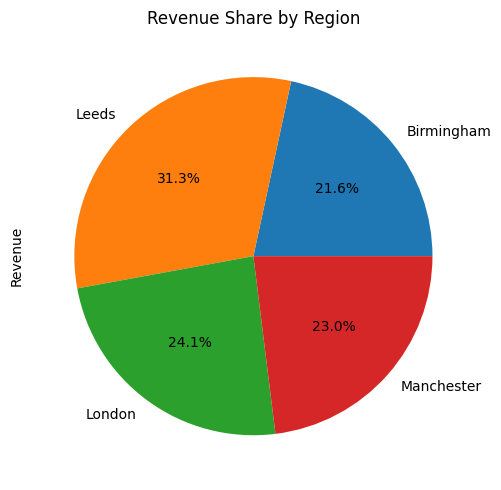


Project Completed Successfully!


In [1]:
# -------------------------------------------
# RETAIL SALES ANALYTICS PROJECT
# End-to-End Python Data Analyst Project
# -------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------
# 1. DATA GENERATION (using Python basics)
# -------------------------------------------

products = ["Laptop", "Mouse", "Keyboard", "Monitor", "Headset"]
regions = ["London", "Manchester", "Birmingham", "Leeds"]

np.random.seed(42)

data = {
    "Product": np.random.choice(products, 200),
    "Region": np.random.choice(regions, 200),
    "Price": np.random.randint(20, 2000, 200),
    "Quantity": np.random.randint(1, 5, 200)
}

df = pd.DataFrame(data)

# Introduce missing values
df.loc[5, "Price"] = np.nan
df.loc[10, "Region"] = np.nan

print("Original Data:\n", df.head())

# -------------------------------------------
# 2. DATA CLEANING
# -------------------------------------------

# Fill missing price with mean
df["Price"] = df["Price"].fillna(df["Price"].mean())

# Fill missing region with mode
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

# Remove duplicates (if any)
df = df.drop_duplicates()

# Create revenue column
df["Revenue"] = df["Price"] * df["Quantity"]

# -------------------------------------------
# 3. APPLY & LAMBDA
# -------------------------------------------
df["Category"] = df["Revenue"].apply(lambda x: "High" if x > 1000 else "Low")

# -------------------------------------------
# 4. GROUPBY ANALYSIS
# -------------------------------------------

# Revenue by product
revenue_by_product = df.groupby("Product")["Revenue"].sum()

# Revenue by region
revenue_by_region = df.groupby("Region")["Revenue"].sum()

# -------------------------------------------
# 5. MERGING DATA (simulate customer data)
# -------------------------------------------

customers = pd.DataFrame({
    "CustomerID": range(1, 201),
    "LoyaltyTier": np.random.choice(["Gold", "Silver", "Bronze"], 200)
})

df["CustomerID"] = customers["CustomerID"]

merged_df = pd.merge(df, customers, on="CustomerID", how="left")

print("\nMerged Data:\n", merged_df.head())

# -------------------------------------------
# 6. VISUALIZATION
# -------------------------------------------

plt.figure(figsize=(8, 5))
revenue_by_product.plot(kind='bar')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
revenue_by_region.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue Share by Region")
plt.tight_layout()
plt.show()

# -------------------------------------------
# 7. EXPORT CLEANED DATA
# -------------------------------------------
merged_df.to_csv("cleaned_sales_data.csv", index=False)

print("\nProject Completed Successfully!")
